# Online Retail Sales Analysis
Data Analysis (EDA)


## Project objectives

The objective of this project is to understand, clean and analyze the online retail dataset using Python (pandas).The project focuses on identifying missing values, duplicate records, inconsistent data, and exploring the dataset before performing exploratory data analysis (EDA).

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
retail = pd.read_csv("OnlineRetail.csv",encoding="ISO-8859-1")

## Dataset Understanding

### Display the First Five Rows

In [3]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Observation 
The first five rows provides an overview of the dataset

### Determine the number of rows and columns

In [4]:
retail.shape

(541909, 8)

### Observation 
The data set contains **541909 rows** and **8 columns**. This indicates that the data set is large enough for meaningful data cleaning and exploratory data analysis.

### Dataset Information

In [6]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Observation 
The dataset contains **8 columns** with different data types, including text('str'), integers ('int64'), and decimal numbers('float64').
The 'Description' and 'CustomerID' columns contain missing values. All other columns have complete data with no missing values.
The 'InvoiceDate' column is currently stored as text ('str') and may need to be converted to a date format during the data cleaning process.

### Summary Statistics

In [5]:
retail.select_dtypes(include=['int64','float64']).columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='str')

In [6]:
retail.select_dtypes(include=['object']).columns

C:\Users\Dell\AppData\Local\Temp\ipykernel_19932\1201719148.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  retail.select_dtypes(include=['object']).columns


Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='str')

### Observation
The dataset contains a mix of text and numeric data. Most columns have the correct data types fpr analysis.InvoiceDate is stored as text and will need to be converted to a datetime format in a later step.

### Unique Values

In [7]:
retail.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

### Observation 
InvoiceNo appears to be the best candidate for a primary key, but it is not unique for every row because one invoice can contain multiple products.

## Data Cleaning

### Count Duplicate Records

In [8]:
retail.duplicated().sum()

np.int64(5268)

### Observation
The dataset contains 5,268 duplicate rows. These duplicate records would be removed during the data cleaning process to improve data quality.

### Remove Duplicate Records

In [9]:
retail = retail.drop_duplicates()

In [12]:
retail.duplicated().sum()

np.int64(0)

In [10]:
retail.shape

(536641, 8)

### Observation
The number of rows decreased after removing duplicate records, while the number of columns remained the same. This comfirms that duplicate rows were successfully removed from the dataset.

### Check for Missing Values

In [14]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

### Observation 
The Description and CustomerID columns have missing values, while other columns have complete data. The missing values needs to be handled before further analysis.

### percentage of missing values

In [11]:
(retail.isnull().sum() / len(retail)) * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64

### Observation 
The 'CustomerID' column has the highest percentage of missing values, while the 'Description' has only a small percentage of missing values. All other columns are complete.

### Handle Missing Values

In [12]:
retail = retail.dropna(subset=["Description","CustomerID"])

### Observation
Rows with missing values in the 'Description' and 'CustomerID' columns were removed to improve the data quality of the dataset before analysis.

### Verify that Missing Values have been removed

In [13]:
retail.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Observation 
All missing values have been successfully removed from the dataset.

### Verify the Final Dataset Shape

In [14]:
retail.shape

(401604, 8)

### Observation 
The final dataset contains **401604 rows** and **8 columns** after removing duplicate records and rows with missing values. The dataset is now ready for exploratory data analysis.

## Exploratory Data Analysis

### Which Country Has the Highest Number of Transactions?

In [15]:
country_transactions = retail["Country"].value_counts()

In [16]:
country_transactions.head(10)

Country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1471
Australia           1258
Name: count, dtype: int64

### Visualize the Top 10 Countries

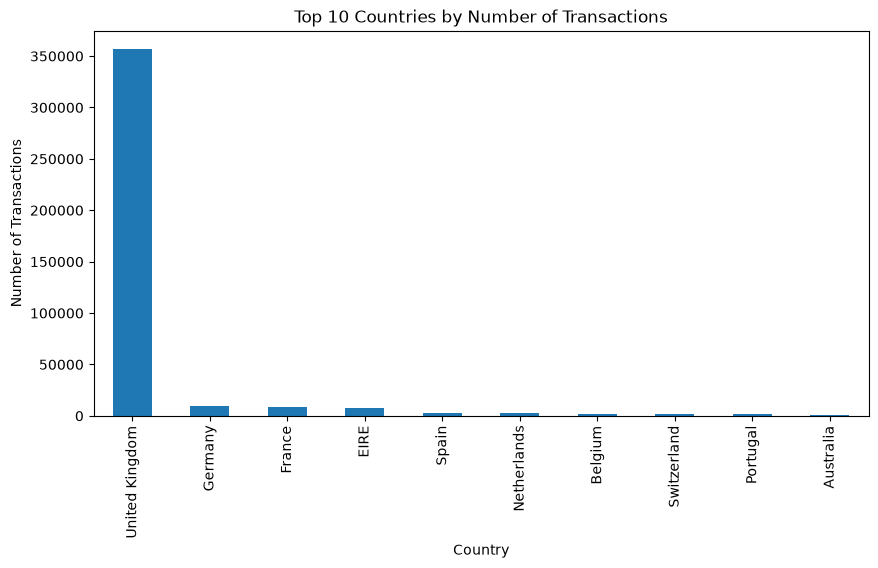

In [27]:
country_transactions.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.show()

### Observation
The United Kingdom has the highest number of transactions in the dataset, followed by other countries with significantly fewer tranasactions.

### Which Products Generated the Highest Sales Revenue?

In [17]:
retail["Sales"] = retail["Quantity"] * retail["UnitPrice"]

In [18]:
top_sales = retail.groupby("Description")["Sales"].sum().sort_values(ascending=False)
top_sales.head(10)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales Revenue')

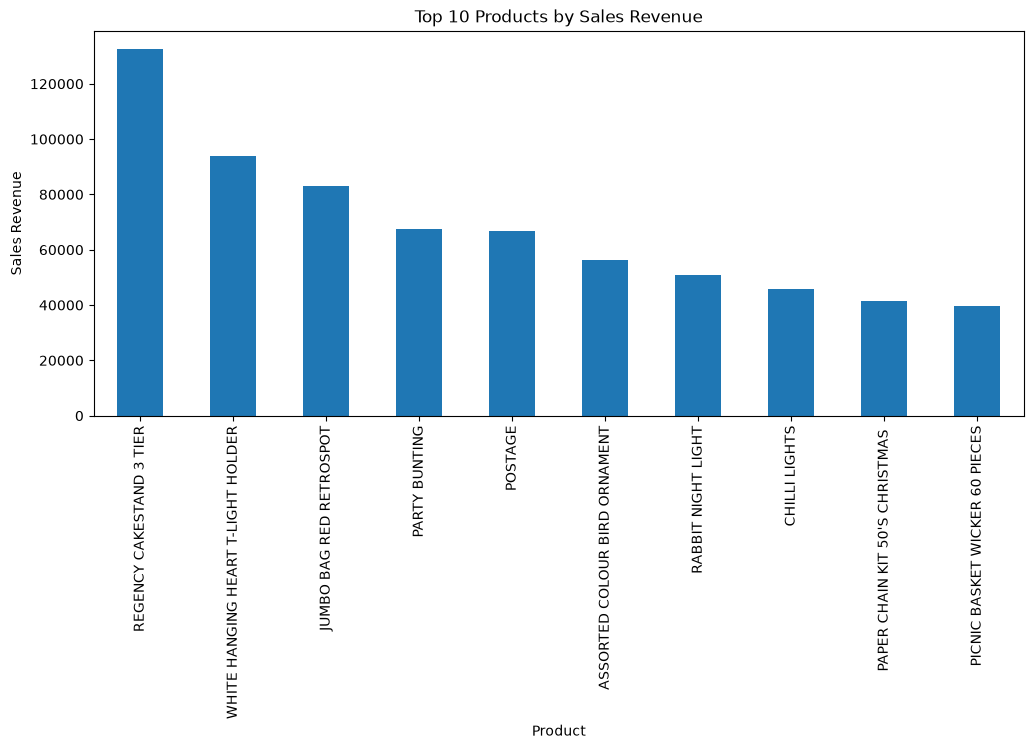

In [66]:
top_sales.head(10).plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Products by Sales Revenue")
plt.xlabel("Product")
plt.ylabel("Sales Revenue")

### Observation 
The chart shows the products thet generated the highest sales revenue. These products contributed the most to the company's revenue and may represent the most valuable items in the business. 

### What is the Monthly Sales Trend?

In [19]:
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

In [20]:
retail["Month"] = retail["InvoiceDate"].dt.to_period("M")

In [21]:
monthly_sales = retail.groupby("Month") ["Sales"].sum()

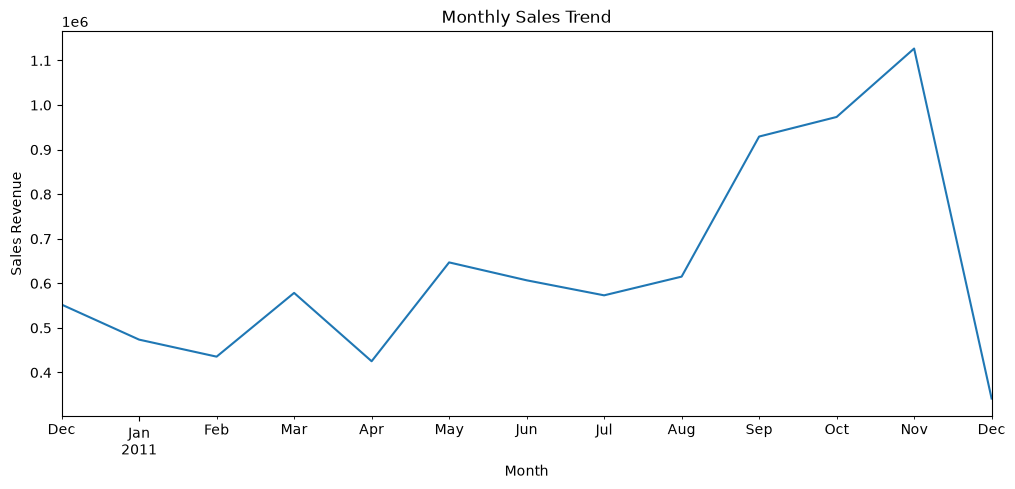

In [26]:
monthly_sales.plot(kind="line", figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Revenue")
plt.show()

### Observation
The 'InvoiceDate' column was converted to a datetime format to enable time-based analysis. A new 'Month' column was created to aggregate sales by month. The line chart shows how sales revenue changed over time, revealing fluctuations in monthly sales that may indicate seasonal customer purchasing patterns.

### Who are the Top 10 Customers by Sales Revenue?

In [22]:
top_customers = retail.groupby("CustomerID") ["Sales"].sum().sort_values(ascending=False)
top_customers.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Sales, dtype: float64

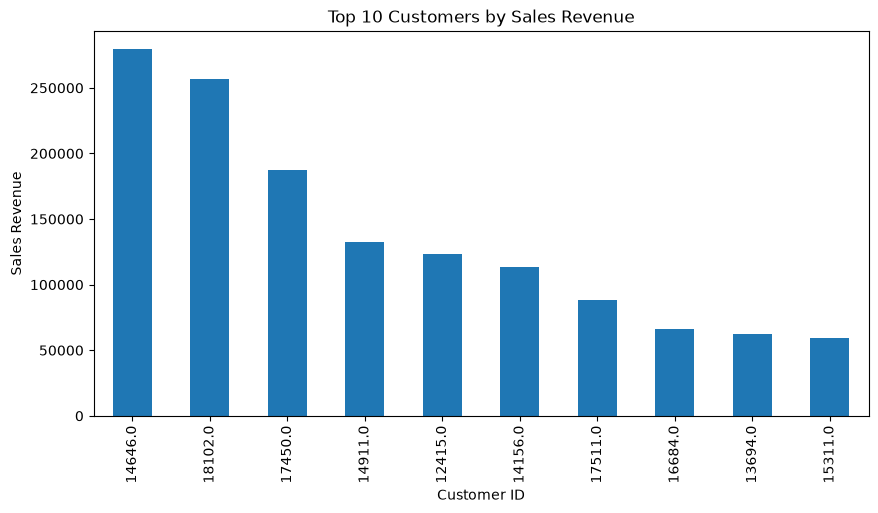

In [23]:
top_customers.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Sales Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Sales Revenue")
plt.show()


### Observation
The analysis identifies the Top 10 Customers based on total sales revenue.
These Customers contributed significantly to the company's revenue and may be valuable candidates for loyalty programs,personalized promotion and customer retention strategies.

### Which Country Generated the Highest Sales Revenue

In [24]:
country_sales = retail.groupby("Country")["Sales"].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Sales, dtype: float64

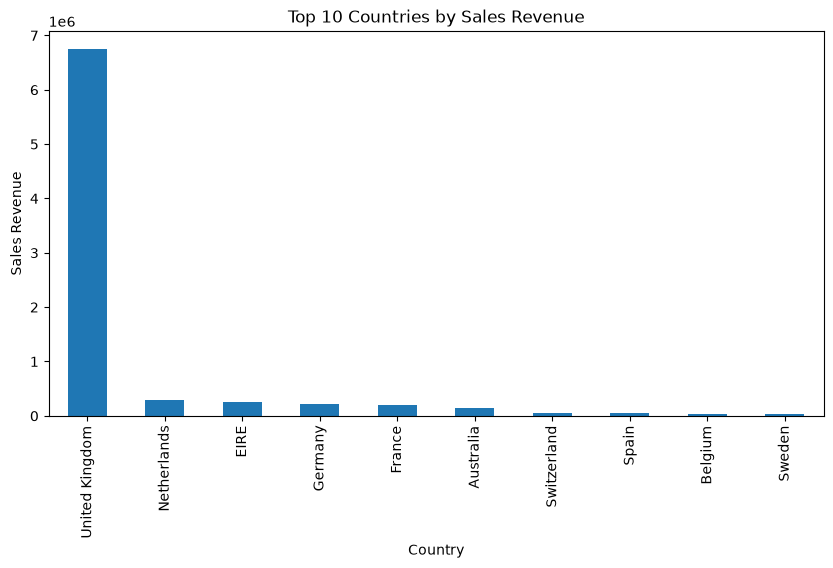

In [25]:
country_sales.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Sales Revenue")
plt.xlabel("Country")
plt.ylabel("Sales Revenue")
plt.show()

### Observation 
The analysis shows the top 10 countries by total revenue. The United Kingdom generated the highest revenue followed by other countries with significantly low sales. This suggests that the United Kingdom is the Company's primary revenue generating market, making it an important region for sales and marketing effors

## Key Findings
-The United Kingdom recorded the highest number of transactions, indicating that it's the company's largest market.

-A small number of products generated a significant share  of the total sales revenue.

-Sales revenue fluctuated throughout the year, with **November recording the highest sales**, indicating a strong seasonal increase in customer purchases.

-The top 10 customers contributed a substantial portion of the company's total sales revenue.

-A few countries generated a majority of the company's sales revenue, highlighting their importance to the business.

## Recommendations 
-Focus marketing efforts on countries that generate the highest sales revenue and maximize business growth.

-Increase targeted marketing campaings in lower-performing countries to encourage sales growth while monitiring their effectiveness.

-Implement custoer loyalty and reward programs to retain high-level customers.

-Ensure that top-selling products remain adequately stocked to meet customer demand.

-Analyze the reasons behind seasonal sales trends and use the insight to improve inventory planning and promotional campaigns.


## Conclusion
This project analyzed the Online Retail Dataset using Python to understand sales performance, customer behavior, and revenue trends. Through data cleaning, feature engineering, and exploratory data analysis, valuable insights were uncovered regarding the company's top performing countries, products, customers, and monthly sales patterns.
These findings can support data driven decision making in areas such as marketing, inventory management, and customer relationship management, ultimately helping the business improve it's overall performance.